Experimental Analysis and Modeling  
----------------------------------------
### Saudi House Price Prediction Using Real Estate Transaction Data

### 1. Imports and configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed. Install it with: pip install xgboost")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_K_FEATURES = 150 

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Locate the dataset

This notebook first tries to load the **model-ready** dataset created in the preprocessing notebook.  
If it is not found, it will try the cleaned dataset, then the renamed dataset, then the raw dataset.

In [2]:
from pathlib import Path

candidate_paths = [
    Path("../dataset/Transactions_sale_for_real_estate_model_ready.csv"),
    Path("../dataset/Transactions_sale_for_real_estate_cleaned.csv"),
    Path("../dataset/Transactions_sale_for_real_estate_renamed.csv"),
    Path("../dataset/Transactions sale for real estate.csv"),
]

existing_paths = [p for p in candidate_paths if p.exists()]
existing_paths

[WindowsPath('../dataset/Transactions_sale_for_real_estate_model_ready.csv'),
 WindowsPath('../dataset/Transactions_sale_for_real_estate_cleaned.csv'),
 WindowsPath('../dataset/Transactions_sale_for_real_estate_renamed.csv'),
 WindowsPath('../dataset/Transactions sale for real estate.csv')]

### 3. Data loading helper

The function below:
- loads the most advanced available file,
- optionally rebuilds preprocessing if only a raw or partially processed dataset exists,
- returns a **model-ready DataFrame**.

In [3]:
def load_and_prepare_dataframe():
    # ---------- 1) Load best available file ----------
    candidate_paths = [
        Path("../dataset/Transactions_sale_for_real_estate_model_ready.csv"),
        Path("../dataset/Transactions_sale_for_real_estate_cleaned.csv"),
        Path("../dataset/Transactions_sale_for_real_estate_renamed.csv"),
        Path("../dataset/Transactions sale for real estate.csv"),
    ]

    existing_paths = [p for p in candidate_paths if p.exists()]
    if not existing_paths:
        raise FileNotFoundError(
            "No dataset file was found. Put one of these files next to the notebook or inside ../dataset/:\n"
            "- Transactions_sale_for_real_estate_model_ready.csv\n"
            "- Transactions_sale_for_real_estate_cleaned.csv\n"
            "- Transactions_sale_for_real_estate_renamed.csv\n"
            "- Transactions sale for real estate.csv"
        )

    data_path = existing_paths[0]
    print(f"Using dataset: {data_path}")
    df = pd.read_csv(data_path)

    # ---------- 2) Rename Arabic columns if needed ----------
    arabic_to_english = {
        "المنطقة": "Region",
        "المدينة": "City",
        "المدينة / الحي": "City / District",
        "الرقم المرجعي للصفقة": "Ref. Number of Transaction",
        "تاريخ الصفقة ميلادي": "Greg. Date of Transaction",
        "تاريخ الصفقة هجري": "Hijri Date of Transaction",
        "تصنيف العقار": "Property Type",
        "السعر": "Price",
        "المساحة": "Area",
        "عدد العقارات": "Number of Properties",
    }
    df = df.rename(columns=arabic_to_english)

    # ---------- 3) If already model-ready, use as-is ----------
    model_ready_signals = {"Log_Price", "Transaction_Year", "Transaction_Month", "Transaction_Day"}
    if "Log_Price" in df.columns and any(col.startswith("Region_") or col.startswith("City_") for col in df.columns):
        print("Detected model-ready dataset.")
        return df, data_path

    # ---------- 4) Preprocess if needed ----------
    print("Detected raw or partially processed dataset. Rebuilding preprocessing inside this notebook...")

    # Remove duplicates
    df = df.drop_duplicates().copy()

    # Convert dates
    for col in ["Greg. Date of Transaction", "Hijri Date of Transaction"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Numeric conversion
    numeric_cols_to_fix = ["Price", "Area", "Number of Properties"]
    for col in numeric_cols_to_fix:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop non-informative ID
    if "Ref. Number of Transaction" in df.columns:
        df = df.drop(columns=["Ref. Number of Transaction"])

    # Date feature engineering
    if "Greg. Date of Transaction" in df.columns:
        df["Transaction_Year"] = df["Greg. Date of Transaction"].dt.year
        df["Transaction_Month"] = df["Greg. Date of Transaction"].dt.month
        df["Transaction_Day"] = df["Greg. Date of Transaction"].dt.day

    # Target transformation
    if "Price" not in df.columns:
        raise ValueError("The dataset must contain a 'Price' column.")
    df["Log_Price"] = np.log1p(df["Price"])

    # Drop raw date columns for modeling
    drop_raw_dates = [c for c in ["Greg. Date of Transaction", "Hijri Date of Transaction"] if c in df.columns]
    df_model_base = df.drop(columns=drop_raw_dates)

    # One-hot encode categorical columns
    categorical_cols = df_model_base.select_dtypes(include=["object"]).columns.tolist()
    df_model_encoded = pd.get_dummies(df_model_base, columns=categorical_cols, drop_first=True)

    # Drop rows with missing target or missing numeric fields after coercion
    df_model_encoded = df_model_encoded.dropna(subset=["Price", "Log_Price"]).copy()

    # Fill any remaining numeric missing values with median
    remaining_na = df_model_encoded.isna().sum().sum()
    if remaining_na > 0:
        numeric_cols = df_model_encoded.select_dtypes(include=[np.number]).columns
        df_model_encoded[numeric_cols] = df_model_encoded[numeric_cols].fillna(df_model_encoded[numeric_cols].median())

    return df_model_encoded, data_path

df_model, source_path = load_and_prepare_dataframe()

print("\nShape:", df_model.shape)
display(df_model.head())

Using dataset: ..\dataset\Transactions_sale_for_real_estate_model_ready.csv
Detected model-ready dataset.

Shape: (48820, 4527)


,Number of Properties,Price,Area,Transaction_Year,Transaction_Month,Transaction_Day,Log_Price,Region_منطقة الجوف,Region_منطقة الحدود الشمالية,Region_منطقة الرياض,Region_منطقة الشرقية,Region_منطقة القصيم,Region_منطقة المدينة المنوره,Region_منطقة تبوك,Region_منطقة جازان,Region_منطقة حائل,Region_منطقة عسير,Region_منطقة مكة المكرمه,Region_منطقة نجران,City_ابها,City_ابو عريش,City_احد المسارحه,City_احد رفيده,City_الاحساء,City_الارطاوي,City_الارطاويه,City_الاسياح,City_الافلاج,City_الباحه,City_البدائع,City_البرك,City_البشائر,City_البكيريه,City_الجبيل,City_الجفر,City_الجموم,City_الحائط,City_الحجره,City_الحرث,City_الحريق,City_الحناكية,City_الخبر,City_الخبراء,City_الخرج,City_الخرمه,City_الخفجي,City_الدائر,City_الدرب,City_الدرعيه,City_الدلم,City_الدمام,City_الدوادمي,City_الرس,City_الروضة,City_الرياض,City_الرين,City_الزلفي,City_السليل,City_السليمي,City_الشقيق,City_الشماسيه,City_الشملى,City_الشنان,City_الطائف,City_الطوال,City_الظهران,City_العارضه,City_العرضيه الجنوبيه,City_العرضيه الشماليه,City_العقيق,City_العويقيله,City_العيدابي,City_العيون,City_الغاط,City_الغزاله,City_القرى,City_القريات,City_القصب,City_القطيف,City_القنفذه,City_القواره,City_القويعيه,City_الكامل,City_الكهفه,City_الليث,City_المجارده,City_المجمعه,City_المخواة,City_المدينة المنورة,City_المذنب,City_المزاحميه,City_المندق,City_المهد,City_المويه,City_النبهانيه,City_النعيريه,City_النماص,City_الهفوف,City_بارق,City_باللسمر,...,City / District_نجران/ الكنتوب,City / District_نجران/ المخيم,City / District_نجران/ المدينه القديمه,City / District_نجران/ المرفض,City / District_نجران/ المطار ب,City / District_نجران/ المعامر,City / District_نجران/ المفرق,City / District_نجران/ النزهه,City / District_نجران/ النهضه,City / District_نجران/ بئر عسكر,City / District_نجران/ برك,City / District_نجران/ ثار,City / District_نجران/ جنوب غرب الحصينية ب 2كم,City / District_نجران/ حبونا,City / District_نجران/ حى الغويلا شرق المطار,City / District_نجران/ دحضة,City / District_نجران/ رجلا,City / District_نجران/ رجلاء فواز,City / District_نجران/ رير,City / District_نجران/ رير درجه 3,City / District_نجران/ شرق الضيافة,City / District_نجران/ شرق الضيافة ب,City / District_نجران/ شرق الضيافه,City / District_نجران/ شرق المطار,City / District_نجران/ شرق المطار أ,City / District_نجران/ شرق المطار ب,City / District_نجران/ شرق المطار ج,City / District_نجران/ شمال الفهد,City / District_نجران/ شمال المنجم,City / District_نجران/ شمال حى الضباط,City / District_نجران/ شمال حى الفهد,City / District_نجران/ صهبان,City / District_نجران/ مخطط الروضة السكنى المعدل,City / District_نجران/ مخطط الغويلا 23,City / District_نجران/ مخطط حى الفهد,City / District_نجران/ مخطط نعيضه بدر الجنوب,City / District_نجران/ مستورة فى الغويلا,City / District_نجران/ نهوقة,City / District_نجران/ نهوقه السكنى,City / District_نجران/أخرى,City / District_هروب/ السران,City / District_هروب/ القتيداء,City / District_هروب/ المشرف,City / District_وادي الدواسر/ الحمدية,City / District_وادي الدواسر/ الخماسين,City / District_وادي الدواسر/ الخماسين الجنوبي,City / District_وادي الدواسر/ الشرافاء,City / District_وادي الدواسر/ القويز,City / District_وادي الدواسر/ المقابل,City / District_وادي الدواسر/ النزهة,City / District_وادي الدواسر/ النويعمة,City / District_وادي الدواسر/ الورود,City / District_وادي الدواسر/ الولامين,City / District_وادي الدواسر/ جنوب الخماسين,City / District_وادي الدواسر/ جنوب النويعمة,City / District_وادي الدواسر/ شرق النويعمة,City / District_وادي الدواسر/أخرى,City / District_وادي الفرع/ الاكحل,City / District_وادي الفرع/ الفقير,City / District_وادي الفرع/ اليتمة,City / District_وادي الفرع/ خارج حدود الاحياء,City / District_وادي الفرع/ وادي الفرع,City / District_وادي الفرع/أخرى,City / District_يدمه/ العزيزية,City / District_يدمه/ خارج حدود الاحياء,City / District_يدمه/ سلطانه,City / District_يدمه/ شرق محافظة يدمه ب 32 كم,City / District_يدمه/ هجر وادي الحبط العزيزية,City / District_يدمه/أخرى,City / District_ينبع/ الجابرية حارة 05 شارع العالية,City / District_ينبع/ الجابرية حارة 08 شارع القضيمة,City / District_ينبع/ الجابرية حاره 08 شارع مستورة,Ci

### 4. Quick data check

In [4]:
print("Dataset shape:", df_model.shape)
print("\nFirst 20 columns:")
print(df_model.columns[:20].tolist())

print("\nMissing values in full dataset:", int(df_model.isna().sum().sum()))
print("Does Log_Price exist?", "Log_Price" in df_model.columns)
print("Does Price exist?", "Price" in df_model.columns)

Dataset shape: (48820, 4527)

First 20 columns:
['Number of Properties', 'Price', 'Area', 'Transaction_Year', 'Transaction_Month', 'Transaction_Day', 'Log_Price', 'Region_منطقة الجوف', 'Region_منطقة الحدود الشمالية', 'Region_منطقة الرياض', 'Region_منطقة الشرقية', 'Region_منطقة القصيم', 'Region_منطقة المدينة المنوره', 'Region_منطقة تبوك', 'Region_منطقة جازان', 'Region_منطقة حائل', 'Region_منطقة عسير', 'Region_منطقة مكة المكرمه', 'Region_منطقة نجران', 'City_ابها']

Missing values in full dataset: 0
Does Log_Price exist? True
Does Price exist? True


### 5. Feature selection, features, and target

This model-ready dataset contains a very large number of one-hot encoded columns.  
To reduce noise and improve model learning, we keep the **top correlated features** with `Log_Price`.

- **Target:** `Log_Price`
- **Dropped from features:** `Log_Price` and raw `Price`
- **Feature selection:** top `TOP_K_FEATURES` numeric features with the strongest absolute correlation with `Log_Price`


In [5]:
if "Log_Price" not in df_model.columns:
    raise ValueError("Log_Price was not found or could not be created.")

target_col = "Log_Price"

# Faster correlation-based feature selection
numeric_df = df_model.select_dtypes(include=["number"])

corr_with_target = (
    numeric_df.drop(columns=[target_col], errors="ignore")
    .corrwith(numeric_df[target_col])
    .abs()
    .sort_values(ascending=False)
)

selected_feature_names = corr_with_target.head(TOP_K_FEATURES).index.tolist()

# Keep raw Price out of X to avoid leakage
selected_feature_names = [c for c in selected_feature_names if c != "Price"]

X = df_model[selected_feature_names].copy()
y = df_model[target_col].copy()

print(f"Selected {len(selected_feature_names)} features out of {df_model.shape[1]-1} available predictors.")
print("\nTop 20 selected features:")
print(selected_feature_names[:20])

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget summary:")
display(y.describe())

Selected 149 features out of 4526 available predictors.

Top 20 selected features:
['Region_منطقة مكة المكرمه', 'City_جده', 'City_الرياض', 'Region_منطقة حائل', 'Region_منطقة القصيم', 'Property Type_سكني', 'City_بقعاء', 'City / District_حفر الباطن/ السلمانية ', 'Region_منطقة الحدود الشمالية', 'City_حفر الباطن', 'City / District_بيش/ الخضراء1 ', 'City_عفيف', 'City_عرعر', 'City_طريب', 'City_بيش', 'Region_منطقة نجران', 'City / District_الطائف/ الورود ', 'City_تثليت', 'Region_منطقة جازان', 'City_الخبر']

X shape: (48820, 149)
y shape: (48820,)

Target summary:


count    48820.000000
mean        12.708423
std          1.424903
min          8.517393
25%         11.951187
50%         12.936036
75%         13.567050
max         20.708690
Name: Log_Price, dtype: float64

### 6. Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set :", X_test.shape, y_test.shape)

Training set: (39056, 149) (39056,)
Testing set : (9764, 149) (9764,)


### 7. Model selection and justification

Three regression models are trained and compared:

- **Ridge Regression**: a regularized linear model that is robust for many correlated predictors.
- **Random Forest Regressor**: an ensemble of decision trees that can model nonlinear relationships.
- **XGBoost Regressor**: a boosted tree model that often performs strongly on structured tabular data.

For this dataset, Ridge provides a strong linear baseline, while Random Forest and XGBoost help test whether nonlinear tree-based models capture additional price patterns.

### 8. Train the models

In [7]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=8,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    print("Ridge, Random Forest, and XGBoost trained successfully.")
else:
    xgb_model = None
    print("Ridge and Random Forest trained successfully. XGBoost was skipped because it is not installed.")

Ridge, Random Forest, and XGBoost trained successfully.


### 9. Generate predictions

In [8]:
ridge_pred_log = ridge_model.predict(X_test)
rf_pred_log = rf_model.predict(X_test)

if xgb_model is not None:
    xgb_pred_log = xgb_model.predict(X_test)
else:
    xgb_pred_log = None

pred_preview = pd.DataFrame({
    "Actual_Log_Price": y_test.values[:10],
    "Ridge_Pred_Log": ridge_pred_log[:10],
    "RF_Pred_Log": rf_pred_log[:10],
})

if xgb_pred_log is not None:
    pred_preview["XGB_Pred_Log"] = xgb_pred_log[:10]

pred_preview

,Actual_Log_Price,Ridge_Pred_Log,RF_Pred_Log,XGB_Pred_Log
0,11.775297,12.277943,12.372319,12.360996
1,12.706851,12.635242,12.469830,12.448674
2,12.899222,12.234135,12.236805,12.155140
3,13.937729,13.650362,13.309105,13.518105
4,11.002117,11.019177,12.031663,11.390587
5,12.592018,13.206485,13.016095,13.135956
6,13.458837,13.341933,13.099891,13.248702
7,14.219793,13.972389,13.858232,13.841435
8,13.122365,13.349110,13.331964,13.384322
9,9.903538,10.521805,11.945425,10.909967


### 10. Evaluation functions

We evaluate on:

#### A) Log scale
This matches the training target.

#### B) Original price scale
This is easier to interpret in Saudi Riyals because we reverse the log transform using `expm1`.

In [9]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def evaluate_model(name, y_true_log, y_pred_log):
    # Log-scale metrics
    metrics_log = regression_metrics(y_true_log, y_pred_log)

    # Original-scale metrics
    y_true_price = np.expm1(y_true_log)
    y_pred_price = np.expm1(y_pred_log)
    metrics_price = regression_metrics(y_true_price, y_pred_price)

    row = {
        "Model": name,
        "MAE_Log": metrics_log["MAE"],
        "RMSE_Log": metrics_log["RMSE"],
        "R2_Log": metrics_log["R2"],
        "MAE_Price": metrics_price["MAE"],
        "RMSE_Price": metrics_price["RMSE"],
        "R2_Price": metrics_price["R2"],
    }
    return row, y_true_price, y_pred_price

### 11. Compute model metrics

In [10]:
ridge_row, ridge_true_price, ridge_pred_price = evaluate_model("Ridge Regression", y_test, ridge_pred_log)
rf_row, rf_true_price, rf_pred_price = evaluate_model("Random Forest", y_test, rf_pred_log)

result_rows = [ridge_row, rf_row]

if xgb_pred_log is not None:
    xgb_row, xgb_true_price, xgb_pred_price = evaluate_model("XGBoost", y_test, xgb_pred_log)
    result_rows.append(xgb_row)

results_df = pd.DataFrame(result_rows).sort_values(by="RMSE_Price").reset_index(drop=True)
results_df

,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Price,RMSE_Price,R2_Price
0,Ridge Regression,0.725627,1.000274,0.528604,712269.248675,5.649338e+06,0.240729
1,XGBoost,0.739663,1.009753,0.519627,739946.719883,6.287775e+06,0.059420
2,Random Forest,0.772548,1.055919,0.474698,755047.847118,6.424320e+06,0.018126


### 12. Interpretation of the metrics

- Lower **MAE** and **RMSE** indicate better predictive accuracy.
- Higher **R²** indicates the model explains more variance in the target.
- Because the target is modeled on the log scale, the **log-scale metrics** are usually more stable and more meaningful for comparison.
- The original price-scale metrics are still useful for practical interpretation, but very expensive properties can make them look much worse.

### 13. Bar chart comparison of model performance

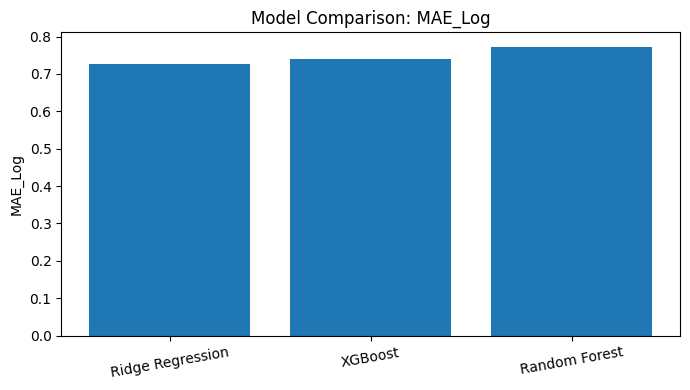

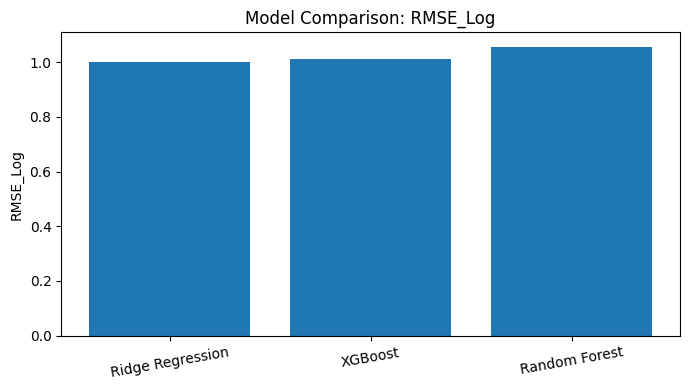

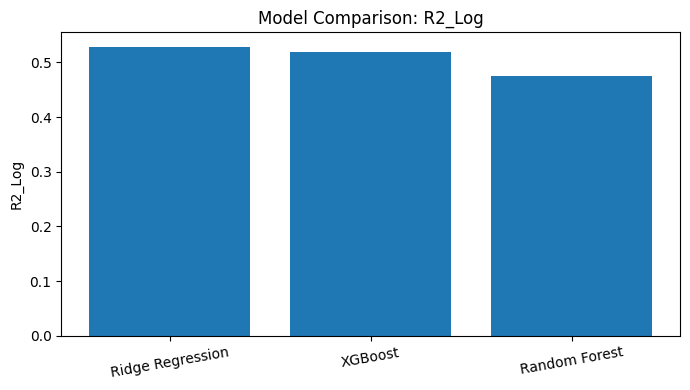

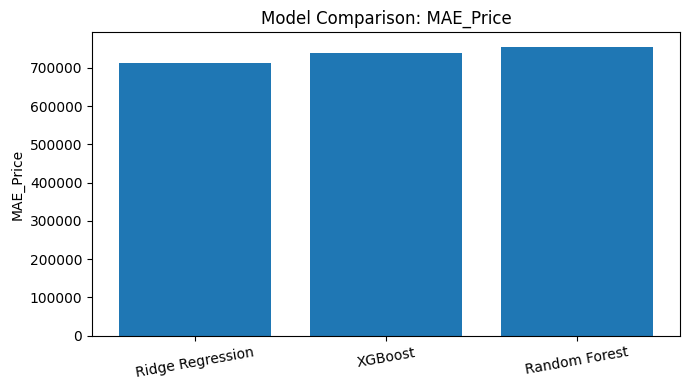

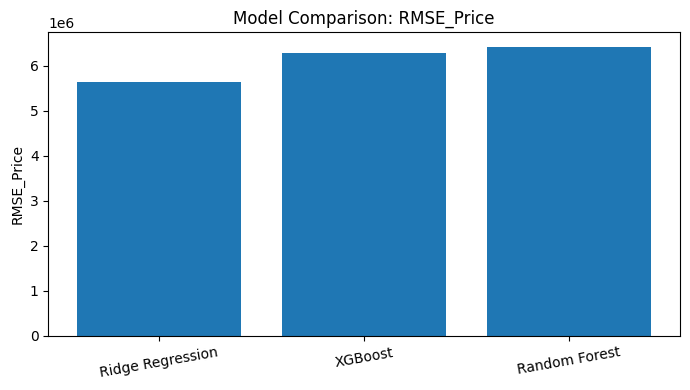

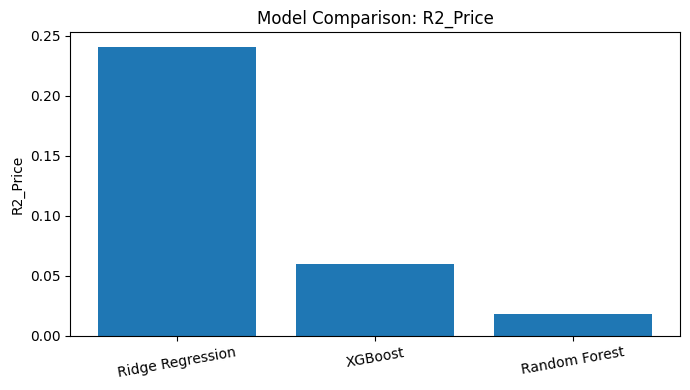

In [11]:
metrics_to_plot = ["MAE_Log", "RMSE_Log", "R2_Log", "MAE_Price", "RMSE_Price", "R2_Price"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()

### 14. Actual vs predicted plots

A good model should produce predictions close to the diagonal line.

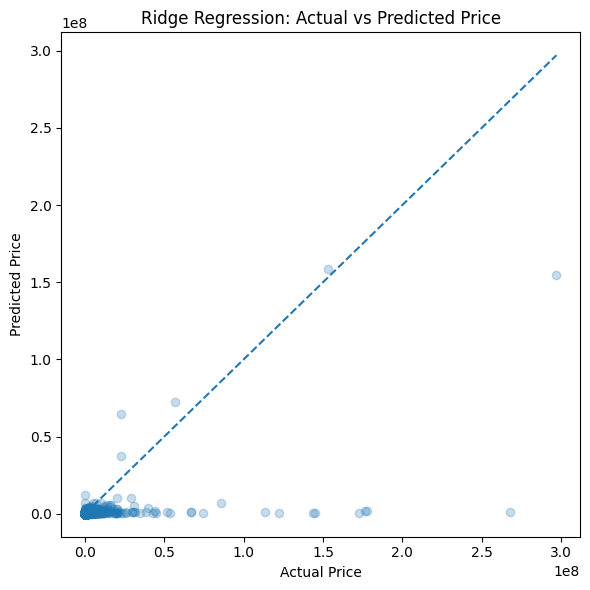

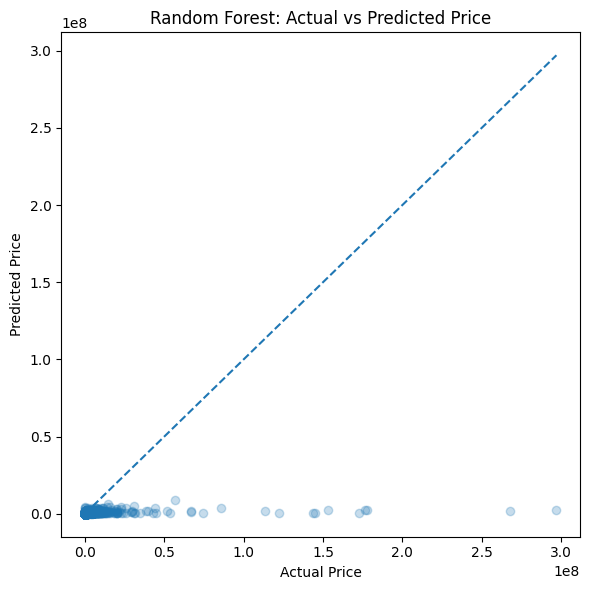

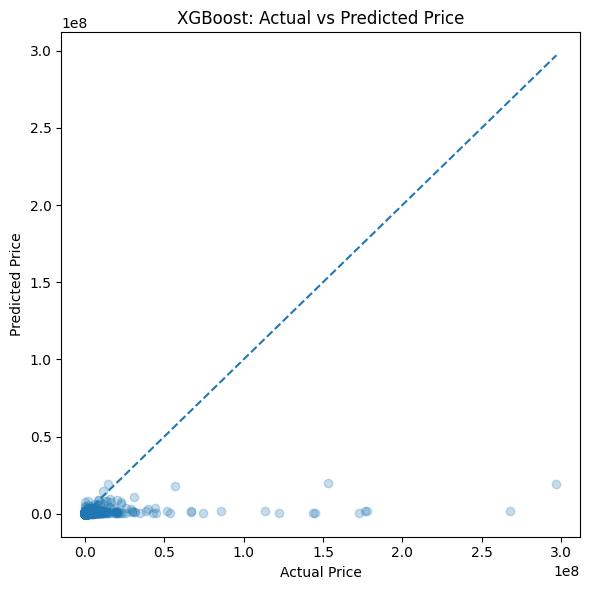

In [12]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.25)
    min_v = min(np.min(y_true), np.min(y_pred))
    max_v = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(ridge_true_price, ridge_pred_price, "Ridge Regression: Actual vs Predicted Price")
plot_actual_vs_predicted(rf_true_price, rf_pred_price, "Random Forest: Actual vs Predicted Price")

if xgb_pred_log is not None:
    plot_actual_vs_predicted(xgb_true_price, xgb_pred_price, "XGBoost: Actual vs Predicted Price")

### 15. Residual analysis

Residuals = Actual - Predicted

A narrower, more centered distribution usually indicates better performance.

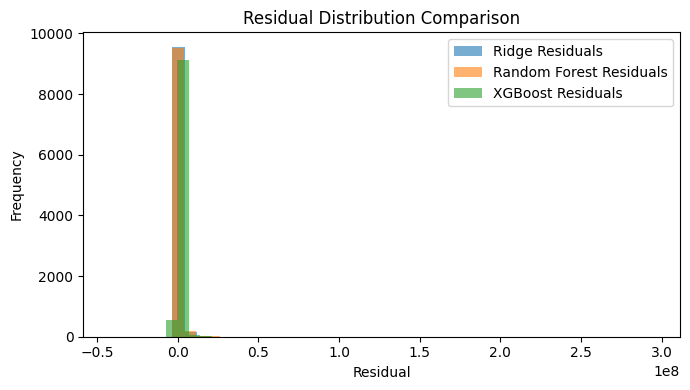

In [13]:
ridge_residuals = ridge_true_price - ridge_pred_price
rf_residuals = rf_true_price - rf_pred_price

plt.figure(figsize=(7, 4))
plt.hist(ridge_residuals, bins=40, alpha=0.6, label="Ridge Residuals")
plt.hist(rf_residuals, bins=40, alpha=0.6, label="Random Forest Residuals")

if xgb_pred_log is not None:
    xgb_residuals = xgb_true_price - xgb_pred_price
    plt.hist(xgb_residuals, bins=40, alpha=0.6, label="XGBoost Residuals")

plt.title("Residual Distribution Comparison")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 16. Top feature importances from tree-based models

Tree-based models can provide a ranking of which predictors contributed most strongly to predictions. Random Forest importances are always shown below. XGBoost importances are also shown if the package is installed.

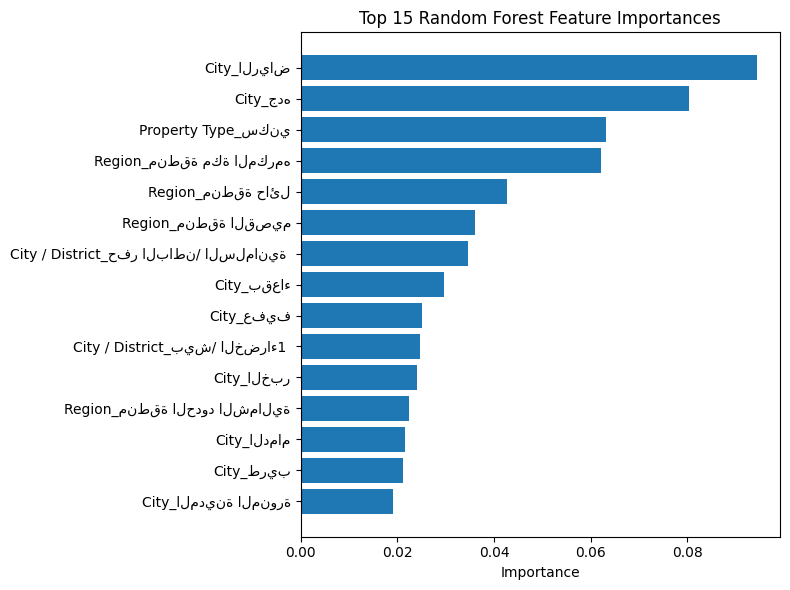

,Importance
City_المدينة المنورة,0.019064
City_طريب,0.021261
City_الدمام,0.021638
Region_منطقة الحدود الشمالية,0.022485
City_الخبر,0.024137
City / District_بيش/ الخضراء1,0.024619
City_عفيف,0.025196
City_بقعاء,0.029718
City / District_حفر الباطن/ السلمانية,0.034702
Region_منطقة القصيم,0.036159


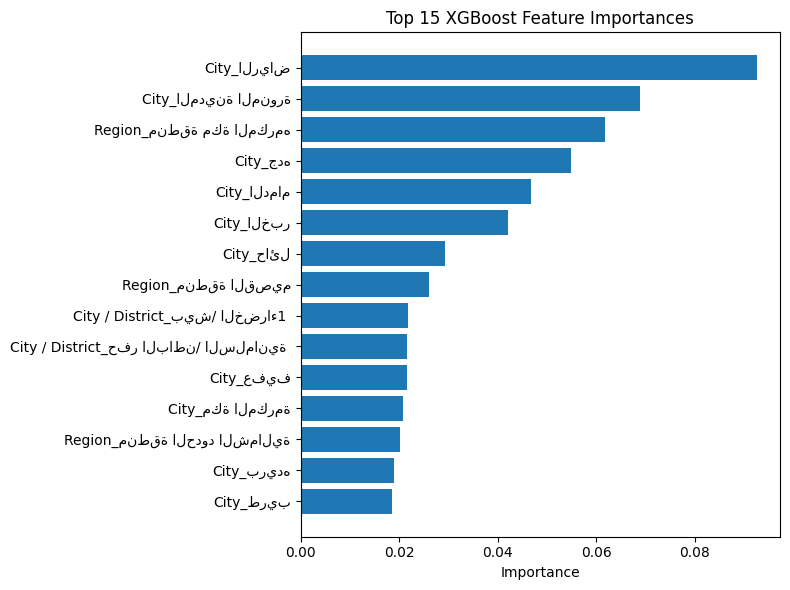

,Importance
City_طريب,0.018519
City_بريده,0.018968
Region_منطقة الحدود الشمالية,0.020203
City_مكة المكرمة,0.020704
City_عفيف,0.021613
City / District_حفر الباطن/ السلمانية,0.021664
City / District_بيش/ الخضراء1,0.021852
Region_منطقة القصيم,0.026038
City_حائل,0.029273
City_الخبر,0.042022


In [14]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 15
top_features = feature_importances.head(top_n).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values)
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(top_features.to_frame("Importance"))

if xgb_model is not None:
    xgb_feature_importances = pd.Series(
        xgb_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    top_xgb_features = xgb_feature_importances.head(top_n).sort_values()

    plt.figure(figsize=(8, 6))
    plt.barh(top_xgb_features.index, top_xgb_features.values)
    plt.title(f"Top {top_n} XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(top_xgb_features.to_frame("Importance"))
else:
    xgb_feature_importances = None

### 17. Save metrics and predictions

In [15]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

results_df.to_csv(output_dir / "model_metrics.csv", index=False)

predictions_df = pd.DataFrame({
    "Actual_Log_Price": y_test.values,
    "Ridge_Pred_Log": ridge_pred_log,
    "RF_Pred_Log": rf_pred_log,
    "Actual_Price": np.expm1(y_test.values),
    "Ridge_Pred_Price": np.expm1(ridge_pred_log),
    "RF_Pred_Price": np.expm1(rf_pred_log),
})

if xgb_pred_log is not None:
    predictions_df["XGB_Pred_Log"] = xgb_pred_log
    predictions_df["XGB_Pred_Price"] = np.expm1(xgb_pred_log)

predictions_df.to_csv(output_dir / "test_predictions.csv", index=False)

feature_importances.to_frame("Importance").to_csv(output_dir / "rf_feature_importances.csv")
pd.DataFrame({"Selected_Features": selected_feature_names}).to_csv(output_dir / "selected_features.csv", index=False)

if xgb_feature_importances is not None:
    xgb_feature_importances.to_frame("Importance").to_csv(output_dir / "xgb_feature_importances.csv")

print("Saved:")
print("-", output_dir / "model_metrics.csv")
print("-", output_dir / "test_predictions.csv")
print("-", output_dir / "rf_feature_importances.csv")
print("-", output_dir / "selected_features.csv")
if xgb_feature_importances is not None:
    print("-", output_dir / "xgb_feature_importances.csv")

Saved:
- ..\outputs\model_metrics.csv
- ..\outputs\test_predictions.csv
- ..\outputs\rf_feature_importances.csv
- ..\outputs\selected_features.csv
- ..\outputs\xgb_feature_importances.csv
